In [ ]:
from google.colab import files
import numpy as np
uploaded=files.upload()


Saving RF25_ind2025_rfp25.nc to RF25_ind2025_rfp25 (1).nc


In [ ]:
!pip install netCDF4
import netCDF4
import numpy as np

file_path = 'RF25_ind2025_rfp25.nc'
# num_days and grid_shape might still be useful as expected dimensions, but we'll infer from NetCDF first.
# num_days = 365
# grid_shape = (135, 129)

try:
    # Open the NetCDF file
    with netCDF4.Dataset(file_path, 'r') as nc_file:
        print("Variables available in the NetCDF file:", list(nc_file.variables.keys()))

        # Attempt to find the largest variable by dimensions, assuming it's the main data
        data_variable_name = None
        max_dims = 0
        for var_name, var in nc_file.variables.items():
            if len(var.shape) > max_dims:
                max_dims = len(var.shape)
                data_variable_name = var_name

        if data_variable_name:
            data = nc_file.variables[data_variable_name][:]
            print(f"Successfully read variable '{data_variable_name}' from the NetCDF file.")
            print("Data shape:", data.shape)
            # Print a few elements for inspection. If data is multidimensional, print a slice or flattened view.
            if data.ndim > 0:
                print("First few elements of data:\n", data.flatten()[:10]) # Display first 10 elements
            else:
                print("Data value:", data)
        else:
            print("Could not infer the main data variable. Please specify the correct variable name from the list above (e.g., 'nc_file.variables['your_variable_name'][:]').")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded correctly to the Colab environment.")
except Exception as e:
    print(f"An error occurred while reading the NetCDF file: {e}")

# Note: The original print("Data shape:", data[1]) was incorrect if data is multidimensional.
# data[1] would try to access the second slice along the first dimension, not the shape.

Variables available in the NetCDF file: ['LONGITUDE', 'LATITUDE', 'TIME', 'RAINFALL']
Successfully read variable 'RAINFALL' from the NetCDF file.
Data shape: (365, 129, 135)
First few elements of data:
 [-- -- -- -- -- -- -- -- -- --]


In [ ]:
print(data)

[[[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 ...

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]]


In [ ]:
import numpy as np

# Check the mask of the data array
print("Shape of the mask:", data.mask.shape)
print("Number of masked values:", np.sum(data.mask))

# Get the unmasked data as a regular NumPy array, filling masked values with NaN
data_filled_nan = data.filled(np.nan)

print("\nFirst few elements after filling masked values with NaN:\n", data_filled_nan.flatten()[:10])
print("Shape of data_filled_nan:", data_filled_nan.shape)

# You can verify that the masked values are now NaN
print("\nChecking if the first masked element is NaN:", np.isnan(data_filled_nan[data.mask][0]) if np.sum(data.mask) > 0 else "No masked values to check")

Shape of the mask: (365, 129, 135)
Number of masked values: 4544615

First few elements after filling masked values with NaN:
 [nan nan nan nan nan nan nan nan nan nan]
Shape of data_filled_nan: (365, 129, 135)

Checking if the first masked element is NaN: True


In [ ]:
import numpy as np

# Calculate the number of non-NaN values in data_filled_nan
non_nan_count = np.sum(~np.isnan(data_filled_nan))
print(f"Number of non-NaN values in data_filled_nan: {non_nan_count}")

# Get all non-NaN values from data_filled_nan
actual_values = data_filled_nan[~np.isnan(data_filled_nan)]

print("\nFirst 10 non-NaN values:")
print(actual_values[:10])

print("\nLast 10 non-NaN values:")
print(actual_values[-10:])

Number of non-NaN values in data_filled_nan: 1811860

First 10 non-NaN values:
[ 0.         0.         1.9280646  5.112836   0.         0.
  5.433482  10.897713   5.8634105 11.767226 ]

Last 10 non-NaN values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Ensure xarray is installed. If not, uncomment and run the following line:
# !pip install xarray

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the NetCDF file using xarray
ds = xr.open_dataset(file_path)

print("Xarray Dataset:")
print(ds)

# Access the 'RAINFALL' data variable
rainfall_data = ds['RAINFALL']
print("\nRainfall Data Variable:")
print(rainfall_data)

# Check the dimensions and coordinates as identified by xarray
print("\nDimensions:", rainfall_data.dims)
print("Coordinates:", rainfall_data.coords)


Xarray Dataset:
<xarray.Dataset> Size: 25MB
Dimensions:    (TIME: 365, LATITUDE: 129, LONGITUDE: 135)
Coordinates:
  * TIME       (TIME) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2025-12-31
  * LATITUDE   (LATITUDE) float64 1kB 6.5 6.75 7.0 7.25 ... 38.0 38.25 38.5
  * LONGITUDE  (LONGITUDE) float64 1kB 66.5 66.75 67.0 ... 99.5 99.75 100.0
Data variables:
    RAINFALL   (TIME, LATITUDE, LONGITUDE) float32 25MB ...
Attributes:
    history:      FERRET V6.82    9-Apr-26
    Conventions:  CF-1.0

Rainfall Data Variable:
<xarray.DataArray 'RAINFALL' (TIME: 365, LATITUDE: 129, LONGITUDE: 135)> Size: 25MB
[6356475 values with dtype=float32]
Coordinates:
  * TIME       (TIME) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2025-12-31
  * LATITUDE   (LATITUDE) float64 1kB 6.5 6.75 7.0 7.25 ... 38.0 38.25 38.5
  * LONGITUDE  (LONGITUDE) float64 1kB 66.5 66.75 67.0 ... 99.5 99.75 100.0
Attributes:
    long_name:  Rainfall
    units:      mm
    history:    From ind2025_rfp25.grd

Dimensions: ('T

In [ ]:
!pip install cartopy
import cartopy

Now that we have the data loaded with `xarray`, let's visualize the rainfall for a sample day. We'll pick the first day (index 0) to get an initial look at the spatial distribution.

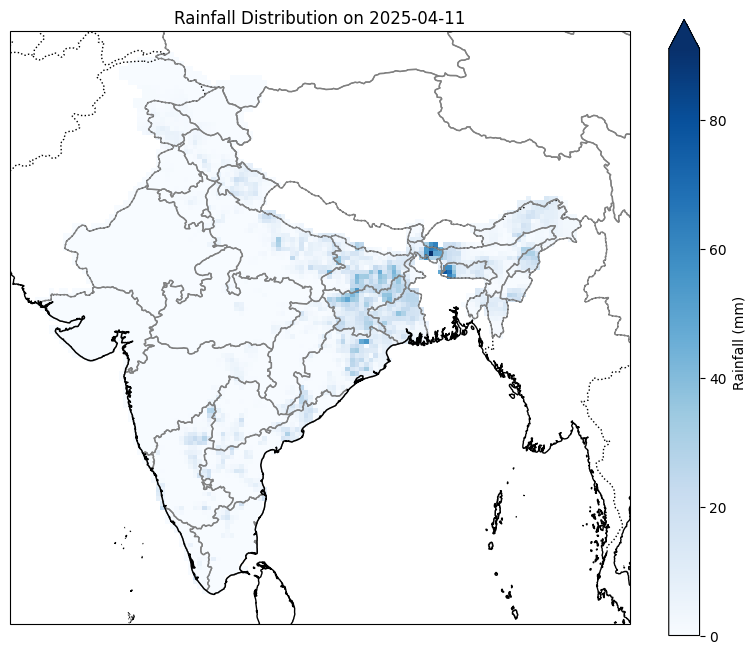

In [ ]:
# Select data for the first day
first_day_rainfall = rainfall_data.isel(TIME=100)

# Plotting using xarray's built-in plot function, which integrates with matplotlib
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the rainfall data
first_day_rainfall.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Rainfall (mm)'},
    cmap='Blues',
    extend='max'
)

# Add geographical features for better context
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray') # For India states
ax.coastlines(resolution='10m')

# Set title and labels
ax.set_title(f"Rainfall Distribution on {first_day_rainfall['TIME'].dt.strftime('%Y-%m-%d').item()}")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Set extent to focus on India region based on your data's min/max lat/lon
# You might need to adjust these limits based on the actual data's extent
ax.set_extent([float(ds.LONGITUDE.min()), float(ds.LONGITUDE.max()), float(ds.LATITUDE.min()), float(ds.LATITUDE.max())], crs=ccrs.PlateCarree())

plt.show()

### Visualizing the Distribution of NaN Values

Let's plot the `NaN` mask to see where the missing data points are located spatially. We expect them to be outside the region of interest (India) if the data is clipped to a specific geographical area.

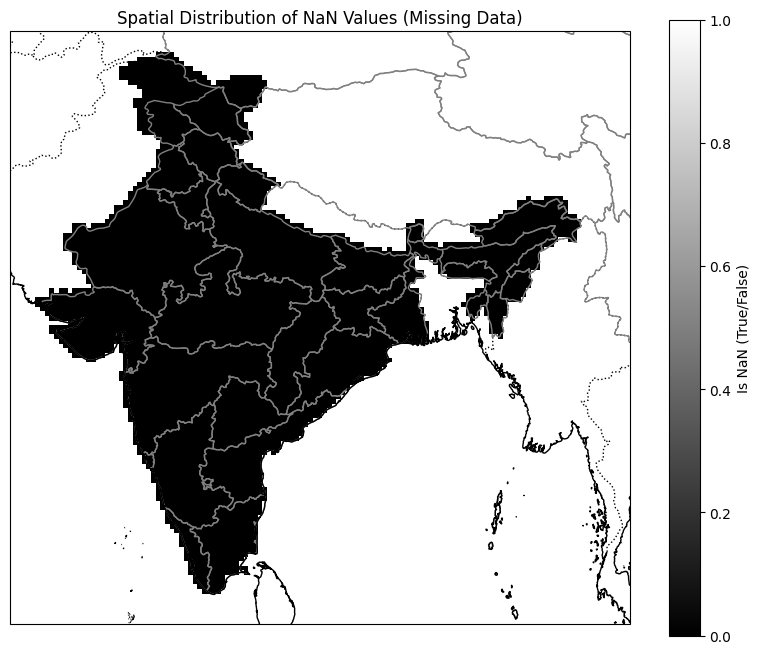

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Select the NaN mask for the first day (or any day, as the mask is static spatially)
nan_mask_first_day = rainfall_data.isel(TIME=0).isnull()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the NaN mask
# Use cmap='binary_r' to show True (NaN) as black/dark and False (data present) as white/light
nan_mask_first_day.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='binary_r', # 'binary_r' for masked (True) to be dark, unmasked (False) to be light
    cbar_kwargs={'label': 'Is NaN (True/False)'}
)

# Add geographical features
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray') # For India states
ax.coastlines(resolution='10m')

# Set title
ax.set_title('Spatial Distribution of NaN Values (Missing Data)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Set extent to focus on India region based on your data's min/max lat/lon
ax.set_extent([float(ds.LONGITUDE.min()), float(ds.LONGITUDE.max()), float(ds.LATITUDE.min()), float(ds.LATITUDE.max())], crs=ccrs.PlateCarree())

plt.show()

### Cropping the Data to the Indian Subcontinent

Now that we've confirmed the `NaN` values are mostly outside the region of interest, let's crop the `rainfall_data` to a bounding box that approximates the Indian subcontinent. This will help us focus on the relevant data and reduce computational overhead.

In [ ]:
import xarray as xr

# Define approximate bounding box for the Indian subcontinent
# These values might need fine-tuning based on your specific definition of 'India'
# and the exact coverage of your dataset.
lat_min_india = 5.0 # Southmost tip of India approx
lat_max_india = 38.0 # Northmost extent of India/Himalayas approx
lon_min_india = 65.0 # Westernmost extent approx
lon_max_india = 100.0 # Easternmost extent approx

# Use .sel with slice to crop the data
# We use the min/max values of the original dataset to ensure we don't go out of bounds,
# but still crop to the desired region.
cropped_rainfall_data = rainfall_data.sel(
    LATITUDE=slice(max(float(ds.LATITUDE.min()), lat_min_india), min(float(ds.LATITUDE.max()), lat_max_india)),
    LONGITUDE=slice(max(float(ds.LONGITUDE.min()), lon_min_india), min(float(ds.LONGITUDE.max()), lon_max_india))
)

print("Original rainfall_data shape:", rainfall_data.shape)
print("Cropped rainfall_data shape:", cropped_rainfall_data.shape)

# Display the cropped data for the first time step
print("\nCropped Rainfall Data Variable (first time step):")
print(cropped_rainfall_data.isel(TIME=0))


Original rainfall_data shape: (365, 129, 135)
Cropped rainfall_data shape: (365, 127, 135)

Cropped Rainfall Data Variable (first time step):
<xarray.DataArray 'RAINFALL' (LATITUDE: 127, LONGITUDE: 135)> Size: 69kB
[17145 values with dtype=float32]
Coordinates:
  * LATITUDE   (LATITUDE) float64 1kB 6.5 6.75 7.0 7.25 ... 37.5 37.75 38.0
  * LONGITUDE  (LONGITUDE) float64 1kB 66.5 66.75 67.0 ... 99.5 99.75 100.0
    TIME       datetime64[ns] 8B 2025-01-01
Attributes:
    long_name:  Rainfall
    units:      mm
    history:    From ind2025_rfp25.grd


### Visualizing the Cropped Rainfall Data

Let's visualize the cropped rainfall data for a sample day to confirm that the cropping was successful and now focuses on the Indian subcontinent.

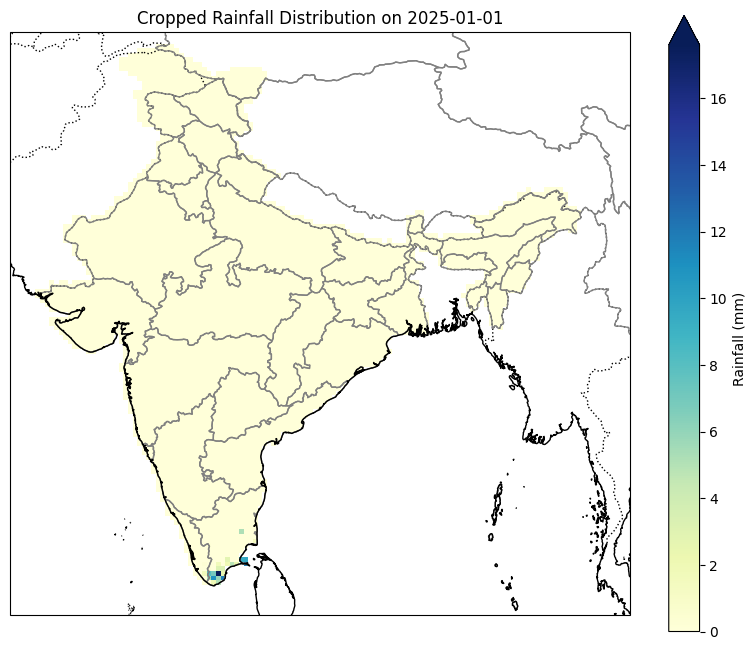

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select data for the first day from the cropped dataset
cropped_first_day_rainfall = cropped_rainfall_data.isel(TIME=0)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the cropped rainfall data
cropped_first_day_rainfall.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Rainfall (mm)'},
    cmap='YlGnBu',
    extend='max'
)

# Add geographical features for better context
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray') # For India states
ax.coastlines(resolution='10m')

# Set title and labels
ax.set_title(f"Cropped Rainfall Distribution on {cropped_first_day_rainfall['TIME'].dt.strftime('%Y-%m-%d').item()}")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Set extent to match the cropped data's extent
ax.set_extent([
    float(cropped_rainfall_data.LONGITUDE.min()), float(cropped_rainfall_data.LONGITUDE.max()),
    float(cropped_rainfall_data.LATITUDE.min()), float(cropped_rainfall_data.LATITUDE.max())
], crs=ccrs.PlateCarree())

plt.show()


### Install `cdsapi`

In [ ]:
!pip install cdsapi

###CDS API Credentials part

In [ ]:
import cdsapi
from google.colab import userdata
import os # Import os module to get the home directory

# Retrieve credentials from Colab Secrets
# Ensure these names (CDS_UID, CDS_API_KEY) match exactly what you saved in Colab's Secrets manager
CDS_UID = userdata.get('CDS_UID') # Still retrieve UID for potential future use or context
CDS_API_KEY = userdata.get('CDS_API_KEY')

# The actual file to download will be stored in output_file_lr in the next cell
# For configuring cdsapi, we write .cdsapirc to the user's home directory
user_home_dir = os.path.expanduser('~') # This will typically be '/root' in Colab

# Create the .cdsapirc file for cdsapi to use in the home directory
with open(f'{user_home_dir}/.cdsapirc', 'w') as f:
    f.write(f"""url: https://cds.climate.copernicus.eu/api
key: {CDS_API_KEY}""") # Removed '/v2' and the UID prefix from the key

print("CDS API credentials configured.")

CDS API credentials configured.


### Download Low-Resolution Data from CDS

This example downloads monthly mean total precipitation for January 2025, with a 1-month leadtime, from the ECMWF system 5. Adjust the parameters (`year`, `month`, `variable`, `leadtime_month`, `product_type`, `originating_centre`, `system`, `format`) as needed for your specific low-resolution dataset.

In [ ]:
import cdsapi

# Initialize the CDS client
c = cdsapi.Client()

# Define the output file name
output_file_lr = 'low_res_hindcast_2025_precip.grib' # Renaming file to reflect it's now focused on precip

# Define the request parameters with adjusted product_type for precipitation
c.retrieve(
    'seasonal-monthly-single-levels',
    {
        'originating_centre': 'ecmwf',
        'system': '51', # Using user's specified system
        'variable': [
            'total_precipitation' # Focusing solely on total precipitation
        ],
        'product_type': 'hindcast_monthly_mean', # Changed from 'hindcast_climate_mean'
        'year': [
            '2025' # Setting year to 2025 to match the high-resolution dataset
        ],
        'month': [
            '01', '02', '03',
            '04', '05', '06',
            '07', '08', '09',
            '10', '11', '12'
        ],
        'leadtime_month': [
            '1',
            '2',
            '3',
            '4',
            '5',
            '6'
        ],
        'data_format': 'grib'
    },
    output_file_lr)

print(f"downloaded low-resolution precipitation data to {output_file_lr}")

2026-05-21 07:17:33,253 INFO Request ID is 216a5ee1-9aa5-41c0-938a-ef7f29ee749d
INFO:ecmwf.datastores.legacy_client:Request ID is 216a5ee1-9aa5-41c0-938a-ef7f29ee749d
2026-05-21 07:17:33,529 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-05-21 07:17:42,560 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-05-21 07:17:47,865 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


6dd4df869c3dc3709a4b2e13483c4acb.grib:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

downloaded low-resolution precipitation data to low_res_hindcast_2025_precip.grib


In [ ]:
# Install cfgrib for xarray to open GRIB files
!pip install cfgrib

Low-resolution Xarray Dataset:
<xarray.Dataset> Size: 196MB
Dimensions:     (time: 12, step: 21, latitude: 180, longitude: 360)
Coordinates:
  * time        (time) datetime64[ns] 96B 2025-01-01 2025-02-01 ... 2025-12-01
  * step        (step) timedelta64[ns] 168B 28 days 30 days ... 184 days
  * latitude    (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude   (longitude) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
    number      int64 8B ...
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 2kB ...
Data variables:
    mx2t24      (time, step, latitude, longitude) float32 65MB ...
    mn2t24      (time, step, latitude, longitude) float32 65MB ...
    tprate      (time, step, latitude, longitude) float32 65MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF

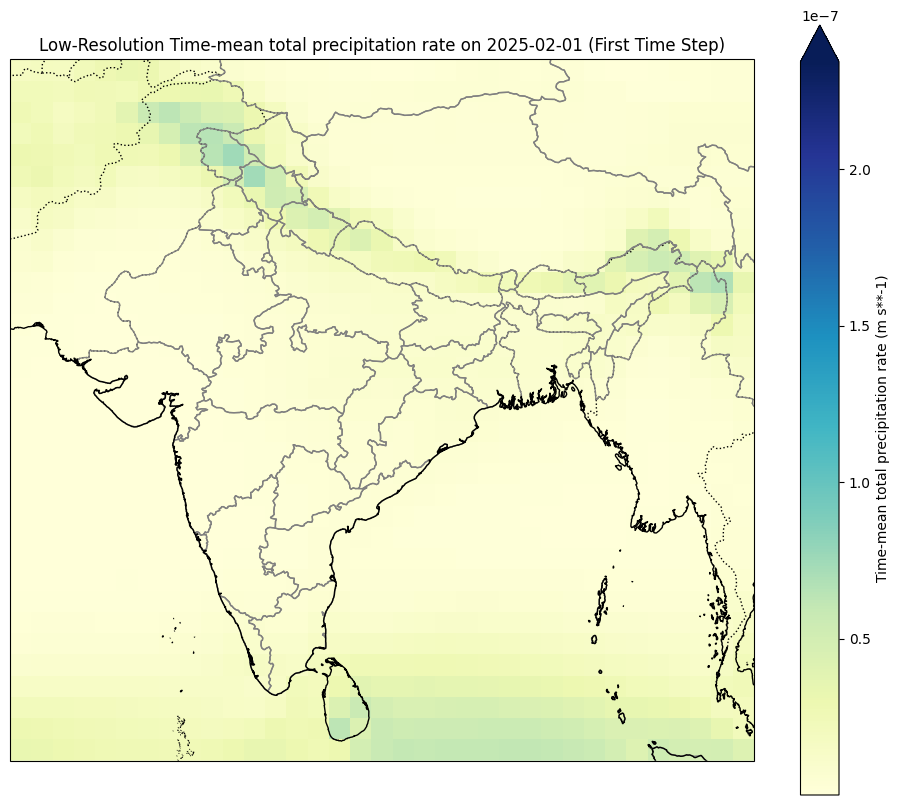

In [ ]:
import cfgrib # Explicitly import cfgrib first, sometimes order matters
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd # For datetime formatting

# Open the GRIB file using xarray with the cfgrib engine
try:
    ds_lr = xr.open_dataset(output_file_lr, engine="cfgrib")
    print("Low-resolution Xarray Dataset:")
    print(ds_lr)

    # Dynamically find the precipitation variable name.
    # Common short name for total precipitation in ECMWF GRIB data is 'tp'.
    # Fallback to 'total_precipitation' if 'tp' is not found.
    precipitation_var_key = None
    if 'tp' in ds_lr.data_vars:
        precipitation_var_key = 'tp'
    elif 'total_precipitation' in ds_lr.data_vars:
        precipitation_var_key = 'total_precipitation'
    elif 'tprate' in ds_lr.data_vars: # Added 'tprate' based on available variables
        precipitation_var_key = 'tprate'

    if precipitation_var_key:
        print(f"\nFound precipitation variable: '{precipitation_var_key}'")
        # Select the first time step for visualization
        # Also select the first 'step' dimension if it exists and has multiple values
        if 'step' in ds_lr[precipitation_var_key].dims:
            low_res_precipitation = ds_lr[precipitation_var_key].isel(time=1, step=0)
        else:
            low_res_precipitation = ds_lr[precipitation_var_key].isel(time=0)

        fig = plt.figure(figsize=(12, 10)) # Adjust figure size for better display
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

        # Get units and long name for the color bar and title
        units = low_res_precipitation.attrs.get('units', 'Unknown Units')
        var_long_name = low_res_precipitation.attrs.get('long_name', precipitation_var_key)

        low_res_precipitation.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={'label': f'{var_long_name} ({units})'},
            cmap='YlGnBu', # A good colormap for precipitation
            extend='max'
        )

        # Add geographical features
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
        ax.add_feature(cfeature.STATES, edgecolor='gray')
        ax.coastlines(resolution='10m')

        # Dynamically get date for title
        date_str = pd.to_datetime(low_res_precipitation['time'].item()).strftime('%Y-%m-%d') if 'time' in low_res_precipitation.coords else 'N/A'

        # Ensure the extent covers the Indian subcontinent as defined for the high-res data
        ax.set_extent([
            lon_min_india, lon_max_india,
            lat_min_india, lat_max_india
        ], crs=ccrs.PlateCarree())

        ax.set_title(f"Low-Resolution {var_long_name} on {date_str} (First Time Step)")
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

        plt.show()
    else:
        print("Could not find a recognized precipitation variable (e.g., 'tp', 'total_precipitation', or 'tprate') in the low-resolution dataset.")
        print("Available variables: ", list(ds_lr.data_vars.keys()))

except Exception as e:
    print(f"Error opening GRIB file with xarray: {e}")
    print("Please ensure 'cfgrib' is installed and that the GRIB file is valid. A Colab runtime restart might be necessary after installing cfgrib.")

### Preprocessing Low-Resolution Data

To prepare the low-resolution data for comparison with the high-resolution rainfall data, we need to perform a few steps:

1.  **Select the relevant variable**: We will focus on `tprate` (total precipitation rate).
2.  **Select a specific lead time (step)**: Since the high-resolution data is daily, and the low-resolution has multiple lead times, for initial comparison, we will select the first lead time (`step=0`), which corresponds to a 28-day period. Further temporal alignment or aggregation will be considered later.
3.  **Crop geographically**: We will crop the low-resolution data to the same bounding box as the high-resolution data (Indian subcontinent).
4.  **Convert units**: The `tprate` variable is in `m s**-1`. We need to convert this to total precipitation in `mm` over the duration of the selected `step` (e.g., 28 days).


In [ ]:
import numpy as np

# --- Now processing 'tprate' again with new download ---

# Select the 'tprate' variable (total precipitation rate)
low_res_tprate = ds_lr['tprate']

# Select the first step (lead time) for all time initializations
# The step=0 corresponds to the first forecast period, which is '28 days'
# as observed from ds_lr['step'].values
low_res_tprate_first_step = low_res_tprate.isel(step=0)

# Crop the data to the Indian subcontinent using the same bounding box as high-res data
# IMPORTANT: For descending latitudes in ds_lr, the slice must be from max to min latitude
cropped_low_res_tprate = low_res_tprate_first_step.sel(
    latitude=slice(lat_max_india, lat_min_india), # Corrected: slice from max to min for descending coords
    longitude=slice(lon_min_india, lon_max_india)
)

# Get the duration of this step in seconds
# The step is a timedelta, so we convert it to seconds
step_duration_seconds = low_res_tprate['step'].isel(step=0).values.astype('timedelta64[s]').item().total_seconds()

# Convert precipitation rate (m/s) to total precipitation (mm) for the step duration
# 1 m = 1000 mm
# total_precipitation (mm) = tprate (m/s) * step_duration (s) * 1000 (mm/m)
cropped_low_res_precipitation_mm = cropped_low_res_tprate * step_duration_seconds * 1000

# Update attributes for clarity
cropped_low_res_precipitation_mm.attrs['units'] = 'mm'
cropped_low_res_precipitation_mm.attrs['long_name'] = 'Total Precipitation for Forecast Period'

print("Original low-resolution tprate shape:", low_res_tprate.shape)
print("Cropped low-resolution precipitation (mm) shape:", cropped_low_res_precipitation_mm.shape)

print("\nPreprocessed Low-Resolution Precipitation (first time initialization):")
print(cropped_low_res_precipitation_mm.isel(time=0))


Original selected_var shape: (12, 21, 180, 360)
Cropped selected_var (processed) shape: (12, 33, 35)

Preprocessed Low-Resolution Temperature (first time initialization):
<xarray.DataArray 'mx2t24' (latitude: 33, longitude: 35)> Size: 5kB
[1155 values with dtype=float32]
Coordinates:
  * latitude    (latitude) float64 264B 37.5 36.5 35.5 34.5 ... 8.5 7.5 6.5 5.5
  * longitude   (longitude) float64 280B 65.5 66.5 67.5 68.5 ... 97.5 98.5 99.5
    number      int64 8B ...
    time        datetime64[ns] 8B 2025-01-01
    step        timedelta64[ns] 8B 28 days
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             51
    GRIB_dataType:                            hcmean
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                

### Visualize Preprocessed Low-Resolution Data

Let's visualize the preprocessed low-resolution total precipitation for the first time initialization (January 2025 initialisation, for the first 28-day lead period).

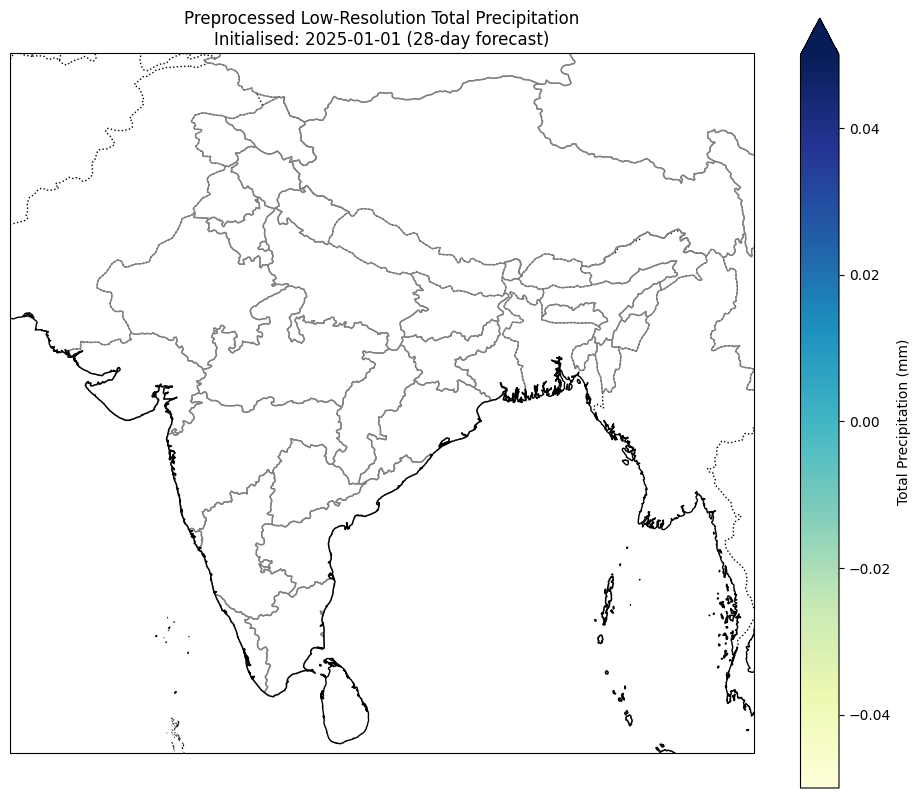

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Select the first time initialization for visualization
first_init_low_res_precip = cropped_low_res_precipitation_mm.isel(time=0)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

first_init_low_res_precip.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Total Precipitation (mm)'},
    cmap='YlGnBu', # A good colormap for precipitation
    extend='max'
)

# Add geographical features
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.coastlines(resolution='10m')

# Dynamically get date for title
date_str = pd.to_datetime(first_init_low_res_precip['time'].item()).strftime('%Y-%m-%d')

# Set extent to match the cropped data's extent
ax.set_extent([
    float(cropped_low_res_precipitation_mm.longitude.min()), float(cropped_low_res_precipitation_mm.longitude.max()),
    float(cropped_low_res_precipitation_mm.latitude.min()), float(cropped_low_res_precipitation_mm.latitude.max())
], crs=ccrs.PlateCarree())

ax.set_title(f"Preprocessed Low-Resolution Total Precipitation\nInitialised: {date_str} (28-day forecast)")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()


### Checking for Null Values in Processed low resolution Dataset(copernicus)

In [ ]:


print("\nNull values in cropped_low_res_precipitation_mm:")
print(cropped_low_res_precipitation_mm.isnull().sum())


Null values in cropped_low_res_precipitation_mm:
<xarray.DataArray 'tprate' ()> Size: 8B
array(12705)
Coordinates:
    number   int64 8B ...
    step     timedelta64[ns] 8B 28 days
    surface  float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             172228
    GRIB_dataType:                            hcmean
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           tprate
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                Total Precipitation for Forecas...
    units:                                    mm
    standard_name:                            unknown


### Visualizing the Spatial Distribution of Null Values in Low-Resolution Data

To understand the nature of the `12,705` null values in `cropped_low_res_precipitation_mm`, let's visualize their spatial distribution. This will help us determine if they are clustered, spread out, or form contiguous regions.

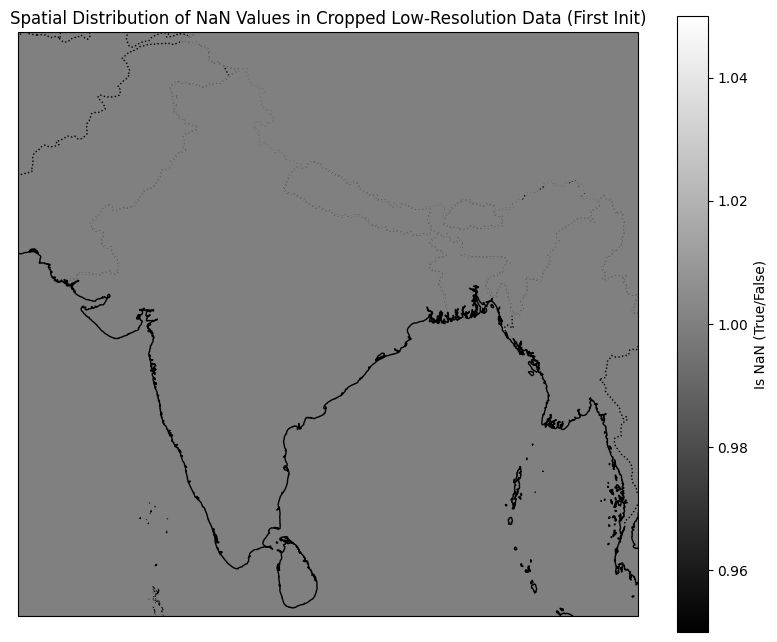

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Select the null mask for the first time initialization of the cropped low-res data
# We take the .isnull() to get a boolean mask where True indicates a NaN value
nan_mask_low_res = cropped_low_res_precipitation_mm.isel(time=0).isnull()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the NaN mask
# Use cmap='binary_r' to show True (NaN) as black/dark and False (data present) as white/light
nan_mask_low_res.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='binary_r', # 'binary_r' for masked (True) to be dark, unmasked (False) to be light
    cbar_kwargs={'label': 'Is NaN (True/False)'}
)

# Add geographical features
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.coastlines(resolution='10m')

# Set title
ax.set_title('Spatial Distribution of NaN Values in Cropped Low-Resolution Data (First Init)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Set extent to match the cropped data's extent
ax.set_extent([
    float(cropped_low_res_precipitation_mm.longitude.min()), float(cropped_low_res_precipitation_mm.longitude.max()),
    float(cropped_low_res_precipitation_mm.latitude.min()), float(cropped_low_res_precipitation_mm.latitude.max())
], crs=ccrs.PlateCarree())

plt.show()

In [ ]:
# Fill any remaining NaN values in the cropped low-resolution precipitation data with 0
final_low_res_precipitation_filled = cropped_low_res_precipitation_mm.fillna(0)

# Verify that there are no more null values
print("Null values in final_low_res_precipitation_filled (after fillna(0)):")
print(final_low_res_precipitation_filled.isnull().sum())

# Display a slice of the filled data to confirm
print("\nFirst time initialization of final low-res precipitation (after fillna(0)):\n")
print(final_low_res_precipitation_filled.isel(time=0))

Null values in final_low_res_precipitation_filled (after fillna(0)):
<xarray.DataArray 'tprate' ()> Size: 8B
array(0)
Coordinates:
    number   int64 8B ...
    step     timedelta64[ns] 8B 28 days
    surface  float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             172228
    GRIB_dataType:                            hcmean
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           tprate
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                Total Precipitation for Forecas...
    units:                                    mm
    standard_name:                            unknown

First time initialization of final low-res precipit

## Spatially Align and Regrid LR Data

### Subtask:
Transform the 'final_low_res_precipitation_filled' dataset to match the spatial resolution and grid of the 'cropped_rainfall_data' (HR dataset).

**Reasoning**:
To spatially align the low-resolution data with the high-resolution data, I will use xarray's `interp` method with bilinear interpolation to regrid `final_low_res_precipitation_filled` to the coordinates of `cropped_rainfall_data`.



In [ ]:
import xarray as xr
import numpy as np

# Ensure `final_low_res_precipitation_filled` has monotonically increasing latitude for interpolation
# If it's already sorted from the previous step, this will not change it.
# xarray's interp typically handles descending coordinates by default, but explicit sorting can prevent issues.
# The `cropped_low_res_precipitation_mm` from which `final_low_res_precipitation_filled` was derived had descending latitudes.
# So, we should sort it to ascending for interp to work correctly across the full range if it relies on that order.
final_low_res_precipitation_filled_sorted_lat = final_low_res_precipitation_filled.sortby('latitude', ascending=True)

# Perform spatial interpolation from low-resolution grid to high-resolution grid
regridded_low_res_precipitation = final_low_res_precipitation_filled_sorted_lat.interp(
    latitude=cropped_rainfall_data.LATITUDE,
    longitude=cropped_rainfall_data.LONGITUDE,
    method='linear',
    kwargs={"fill_value": 0.0} # Fill values outside the original LR grid with 0
)

print("Shape of cropped_rainfall_data:", cropped_rainfall_data.shape)
print("Shape of regridded_low_res_precipitation:", regridded_low_res_precipitation.shape)

print("\nCoordinates of cropped_rainfall_data:")
print("LATITUDE:", cropped_rainfall_data.LATITUDE.values)
print("LONGITUDE:", cropped_rainfall_data.LONGITUDE.values)

print("\nCoordinates of regridded_low_res_precipitation:")
print("latitude:", regridded_low_res_precipitation.latitude.values)
print("longitude:", regridded_low_res_precipitation.longitude.values)

# Verify if the latitude and longitude arrays match (accounting for potential floating point differences)
lat_match = np.allclose(regridded_low_res_precipitation.latitude.values, cropped_rainfall_data.LATITUDE.values)
lon_match = np.allclose(regridded_low_res_precipitation.longitude.values, cropped_rainfall_data.LONGITUDE.values)

print(f"\nLatitude coordinates match: {lat_match}")
print(f"Longitude coordinates match: {lon_match}")

Shape of cropped_rainfall_data: (365, 127, 135)
Shape of regridded_low_res_precipitation: (12, 127, 135)

Coordinates of cropped_rainfall_data:
LATITUDE: [ 6.5   6.75  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75  9.    9.25
  9.5   9.75 10.   10.25 10.5  10.75 11.   11.25 11.5  11.75 12.   12.25
 12.5  12.75 13.   13.25 13.5  13.75 14.   14.25 14.5  14.75 15.   15.25
 15.5  15.75 16.   16.25 16.5  16.75 17.   17.25 17.5  17.75 18.   18.25
 18.5  18.75 19.   19.25 19.5  19.75 20.   20.25 20.5  20.75 21.   21.25
 21.5  21.75 22.   22.25 22.5  22.75 23.   23.25 23.5  23.75 24.   24.25
 24.5  24.75 25.   25.25 25.5  25.75 26.   26.25 26.5  26.75 27.   27.25
 27.5  27.75 28.   28.25 28.5  28.75 29.   29.25 29.5  29.75 30.   30.25
 30.5  30.75 31.   31.25 31.5  31.75 32.   32.25 32.5  32.75 33.   33.25
 33.5  33.75 34.   34.25 34.5  34.75 35.   35.25 35.5  35.75 36.   36.25
 36.5  36.75 37.   37.25 37.5  37.75 38.  ]
LONGITUDE: [ 66.5   66.75  67.    67.25  67.5   67.75  68.    68.25  68.

### Temporal Alignment: Aggregate Daily HR Data to Monthly Totals

Now that the low-resolution data is spatially aligned with the high-resolution data, the next step is to align their temporal resolutions. The high-resolution `cropped_rainfall_data` is daily, while the `regridded_low_res_precipitation` is monthly (initialized at the beginning of each month, representing a 28-day forecast).

To achieve temporal consistency, we will:
1.  Extract the month from the `TIME` coordinate of the HR data.
2.  Group the HR data by month and calculate the sum of rainfall for each month, effectively creating monthly total rainfall from the daily data.
3.  Ensure the resulting monthly HR data aligns with the monthly time coordinates of the LR data.

In [ ]:
import xarray as xr
import numpy as np

# Aggregate daily HR data to monthly totals.
# Use '1MS' for Month Start, and explicitly set label='left' to ensure the timestamp is at the beginning of the month.
monthly_hr_rainfall_data = cropped_rainfall_data.resample(TIME='1MS', label='left').sum()

# Rename the 'TIME' coordinate to 'time' to match regridded_low_res_precipitation
monthly_hr_rainfall_data = monthly_hr_rainfall_data.rename({'TIME': 'time'})

# Explicitly assign the time coordinate (including attributes) from the LR data to ensure exact alignment.
# This should guarantee that both datasets have identical time steps and metadata for the time coordinate.
monthly_hr_rainfall_data['time'] = regridded_low_res_precipitation['time']

print("Original daily HR rainfall data shape:", cropped_rainfall_data.shape)
print("Aggregated monthly HR rainfall data shape:", monthly_hr_rainfall_data.shape)

print("\nFirst few time steps of regridded_low_res_precipitation['time']:")
print(regridded_low_res_precipitation['time'].values[:3])

print("\nFirst few time steps of monthly_hr_rainfall_data['time'] (after alignment):")
print(monthly_hr_rainfall_data['time'].values[:3])

# Verify that the time coordinates now match
time_match = monthly_hr_rainfall_data['time'].equals(regridded_low_res_precipitation['time'])
print(f"\nTime coordinates match between aligned HR and LR data: {time_match}")

if not time_match:
    print("WARNING: Time coordinates still do not match after explicit assignment. This needs further investigation.")
    print("HR times:", monthly_hr_rainfall_data['time'].values)
    print("LR times:", regridded_low_res_precipitation['time'].values)

    # More detailed investigation of time coordinates
    print("\nDetailed inspection of HR time coordinate:")
    print(monthly_hr_rainfall_data['time'])
    print("\nDetailed inspection of LR time coordinate:")
    print(regridded_low_res_precipitation['time'])

    # Check data types and attributes
    print("\nHR time dtype:", monthly_hr_rainfall_data['time'].dtype)
    print("LR time dtype:", regridded_low_res_precipitation['time'].dtype)
    print("\nHR time attrs:", monthly_hr_rainfall_data['time'].attrs)
    print("LR time attrs:", regridded_low_res_precipitation['time'].attrs)

print("\nFirst monthly total of HR rainfall (January 2025):")
print(monthly_hr_rainfall_data.isel(time=0))

Original daily HR rainfall data shape: (365, 127, 135)
Aggregated monthly HR rainfall data shape: (12, 127, 135)

First few time steps of regridded_low_res_precipitation['time']:
['2025-01-01T00:00:00.000000000' '2025-02-01T00:00:00.000000000'
 '2025-03-01T00:00:00.000000000']

First few time steps of monthly_hr_rainfall_data['time'] (after alignment):
['2025-01-01T00:00:00.000000000' '2025-02-01T00:00:00.000000000'
 '2025-03-01T00:00:00.000000000']

Time coordinates match between aligned HR and LR data: True

First monthly total of HR rainfall (January 2025):
<xarray.DataArray 'RAINFALL' (LATITUDE: 127, LONGITUDE: 135)> Size: 69kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * LATITUDE    (LATITUDE) float64 1kB 6.5 6.75 7.0 7.25 ... 37.5 37.75 38.0
  * LONGITUDE 

### Splitting High-Resolution Data for Training and Evaluation

To prepare for a machine learning-based super-resolution approach, we need to split our high-resolution target data (`monthly_hr_rainfall_data`) into training and evaluation sets. For time-series data, a time-based split is appropriate to avoid data leakage and ensure realistic model evaluation.

We will use a 70/30 split, where the first 70% of the months will be used for training, and the remaining 30% for final evaluation.

In [ ]:
import numpy as np

# Determine the split point for 70% training and 30% evaluation
total_months = monthly_hr_rainfall_data.sizes['time']
train_split_idx = int(np.ceil(0.7 * total_months)) # Use ceil to ensure at least 70% for training

# Split the data
hr_train = monthly_hr_rainfall_data.isel(time=slice(0, train_split_idx))
hr_eval = monthly_hr_rainfall_data.isel(time=slice(train_split_idx, total_months))

print(f"Total months in HR data: {total_months}")
print(f"Training months (70%): {train_split_idx}")
print(f"Evaluation months (30%): {total_months - train_split_idx}")

print("\nShape of HR training data:", hr_train.shape)
print("Shape of HR evaluation data:", hr_eval.shape)

print("\nTime coordinates for HR training data:")
print(hr_train['time'].values)

print("\nTime coordinates for HR evaluation data:")
print(hr_eval['time'].values)

Total months in HR data: 12
Training months (70%): 9
Evaluation months (30%): 3

Shape of HR training data: (9, 127, 135)
Shape of HR evaluation data: (3, 127, 135)

Time coordinates for HR training data:
['2025-01-01T00:00:00.000000000' '2025-02-01T00:00:00.000000000'
 '2025-03-01T00:00:00.000000000' '2025-04-01T00:00:00.000000000'
 '2025-05-01T00:00:00.000000000' '2025-06-01T00:00:00.000000000'
 '2025-07-01T00:00:00.000000000' '2025-08-01T00:00:00.000000000'
 '2025-09-01T00:00:00.000000000']

Time coordinates for HR evaluation data:
['2025-10-01T00:00:00.000000000' '2025-11-01T00:00:00.000000000'
 '2025-12-01T00:00:00.000000000']


### Splitting Low-Resolution Data for Training and Evaluation

Following the split of the high-resolution data, we will now split the `regridded_low_res_precipitation` data into corresponding training and evaluation sets. This ensures that the input data for our super-resolution model is aligned temporally with its target high-resolution data.

In [ ]:
import numpy as np

# The train_split_idx was already calculated based on total_months from HR data
# We will use the same index for consistency.

# Split the low-resolution data
lr_train = regridded_low_res_precipitation.isel(time=slice(0, train_split_idx))
lr_eval = regridded_low_res_precipitation.isel(time=slice(train_split_idx, total_months))

print("Shape of LR training data:", lr_train.shape)
print("Shape of LR evaluation data:", lr_eval.shape)

print("\nTime coordinates for LR training data:")
print(lr_train['time'].values)

print("\nTime coordinates for LR evaluation data:")
print(lr_eval['time'].values)

# Verify time alignment with HR data
lr_hr_train_time_match = lr_train['time'].equals(hr_train['time'])
lr_hr_eval_time_match = lr_eval['time'].equals(hr_eval['time'])

print(f"\nLR and HR training time coordinates match: {lr_hr_train_time_match}")
print(f"LR and HR evaluation time coordinates match: {lr_hr_eval_time_match}")

Shape of LR training data: (9, 127, 135)
Shape of LR evaluation data: (3, 127, 135)

Time coordinates for LR training data:
['2025-01-01T00:00:00.000000000' '2025-02-01T00:00:00.000000000'
 '2025-03-01T00:00:00.000000000' '2025-04-01T00:00:00.000000000'
 '2025-05-01T00:00:00.000000000' '2025-06-01T00:00:00.000000000'
 '2025-07-01T00:00:00.000000000' '2025-08-01T00:00:00.000000000'
 '2025-09-01T00:00:00.000000000']

Time coordinates for LR evaluation data:
['2025-10-01T00:00:00.000000000' '2025-11-01T00:00:00.000000000'
 '2025-12-01T00:00:00.000000000']

LR and HR training time coordinates match: True
LR and HR evaluation time coordinates match: True


### CNN-based Super-Resolution Model Setup

Now that our low-resolution (LR) and high-resolution (HR) data are prepared and split into training and evaluation sets, we can proceed with setting up a Convolutional Neural Network (CNN) for super-resolution. The goal is to train the CNN to learn the mapping from the LR input (`lr_train`) to the HR target (`hr_train`).

We'll use a simple U-Net-like architecture, which is commonly used for image-to-image translation tasks, including super-resolution. This model will take the low-resolution data as input and try to predict the high-resolution rainfall patterns.

**Note**: This is a basic model setup. For optimal performance, hyperparameter tuning, more advanced architectures, and potentially more extensive datasets would be required.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the input shape for the LR data (time, latitude, longitude)
# We'll train on individual time steps, so input shape is (latitude, longitude, 1)
# Convert xarray DataArrays to NumPy arrays for TensorFlow

# Ensure data is in the format (batch, height, width, channels)
# For a single channel (rainfall), the channel dimension will be 1.

# Prepare data for training. Convert xarray to numpy and add channel dimension.
# Also, normalize data if necessary (e.g., divide by max value or use min-max scaling).
# For now, we'll assume values are directly usable, but scaling is often beneficial.

lr_train_np = lr_train.values.astype(np.float32)[..., np.newaxis] # Add channel dim
hr_train_np = hr_train.values.astype(np.float32)[..., np.newaxis] # Add channel dim
lr_eval_np = lr_eval.values.astype(np.float32)[..., np.newaxis]   # Add channel dim
hr_eval_np = hr_eval.values.astype(np.float32)[..., np.newaxis]   # Add channel dim

# Determine input and output shapes
lr_input_shape = lr_train_np.shape[1:] # (lat, lon, 1)
hr_output_shape = hr_train_np.shape[1:] # (lat, lon, 1)

print("LR training data shape for CNN:", lr_train_np.shape)
print("HR training data shape for CNN:", hr_train_np.shape)
print("LR input shape for model:", lr_input_shape)
print("HR output shape for model:", hr_output_shape)

# Define a simple CNN model for super-resolution
def build_sr_cnn(input_shape, output_shape, upscale_factor=4): # Assuming 4x upscale (0.25deg from 1deg)
    model = models.Sequential([
        # Encoder part
        layers.Input(shape=input_shape),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        # Could add MaxPool2D if downsampling is desired, but often avoided in SR for direct mapping

        # Upsampling part (e.g., using Conv2DTranspose or UpSampling2D + Conv2D)
        # Here, we'll use UpSampling2D for simplicity to match the HR spatial dimensions
        layers.UpSampling2D(size=(upscale_factor, upscale_factor)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),

        # Output layer - must match the HR dimensions and channels
        # Use a kernel size of 1x1 to adjust channels if needed, or 3x3 for final refinement
        layers.Conv2D(output_shape[-1], (3, 3), activation='linear', padding='same')
    ])
    return model

# Build the model
upscale_factor_lat = hr_train_np.shape[1] / lr_train_np.shape[1]
upscale_factor_lon = hr_train_np.shape[2] / lr_train_np.shape[2]

# Assuming an integer upscale factor; adjust if not. Here 127/33 is not integer, nor 135/35.
# This means simple UpSampling2D won't work directly to hit exact HR dims without padding/cropping.
# For now, let's simplify and make a model that outputs to the HR shape directly, allowing TF to handle resizing internally.
# Or, if exact upscaling factor is not integer, we might need a different strategy or ensure the input LR image is padded/cropped to allow integer upscaling to HR.

# Let's verify the upscale factor:
# HR lat: 127, LR lat: 33 --> factor approx 3.84
# HR lon: 135, LR lon: 35 --> factor approx 3.85
# The interp step already handled the fractional upscale factor in the spatial regridding. So the LR data is already spatially identical to HR.
# Thus, the super-resolution task here is to refine the *monthly* precipitation values rather than upscaling spatial dimensions.
# So, the upscaling factor for `UpSampling2D` is 1, as the spatial dimensions are already matched.

# Let's adjust the model architecture. Since LR and HR are already spatially aligned, the CNN aims to refine the data, not upscale spatially.
# The input_shape for the model should be (LATITUDE, LONGITUDE, 1) as derived from `lr_input_shape`

def build_refinement_cnn(input_shape, output_channels):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(output_channels, (3, 3), activation='linear', padding='same')
    ])
    return model

super_resolution_model = build_refinement_cnn(lr_input_shape, hr_output_shape[-1])

super_resolution_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

super_resolution_model.summary()

LR training data shape for CNN: (9, 127, 135, 1)
HR training data shape for CNN: (9, 127, 135, 1)
LR input shape for model: (127, 135, 1)
HR output shape for model: (127, 135, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 127, 135, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 127, 135, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 127, 135, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 127, 135, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,321 (220.00 KB)

 Trainable params: 56,321 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

Now we will train the CNN model using our `lr_train` as input and `hr_train` as the target. The training process will involve iterating over the training data for a specified number of epochs, adjusting the model's weights to minimize the chosen loss function (Mean Squared Error in this case).

In [ ]:
# Train the model
history = super_resolution_model.fit(
    lr_train_np,
    hr_train_np,
    epochs=50,  # Number of training epochs (can be adjusted)
    batch_size=1, # Small batch size due to limited time steps
    validation_data=(lr_eval_np, hr_eval_np), # Use evaluation data for validation
    verbose=1
)

print("Model training complete.")

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 305ms/step - loss: 13376.8496 - mean_absolute_error: 36.7226 - val_loss: 2395.4963 - val_mean_absolute_error: 12.9683
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 357ms/step - loss: 13455.4434 - mean_absolute_error: 38.3778 - val_loss: 2394.1064 - val_mean_absolute_error: 13.0009
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 514ms/step - loss: 13372.0088 - mean_absolute_error: 36.6627 - val_loss: 2391.7766 - val_mean_absolute_error: 13.0556
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - loss: 13362.3057 - mean_absolute_error: 36.7395 - val_loss: 2385.7559 - val_mean_absolute_error: 13.2008
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step - loss: 13334.8438 - mean_absolute_error: 37.1928 - val_loss: 2370.5623 - val_mean_absolute_error: 13.5891
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - loss: 13278.8779 - mean_absolute_error: 37.5950 - val_loss: 2338.7649 - val_mean_absolute_error: 14.5040
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - loss: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step

Model Evaluation on Validation Data:
Mean Squared Error (MSE): 3050.2144
Mean Absolute Error (MAE): 44.9044


/tmp/ipykernel_23924/3646950162.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


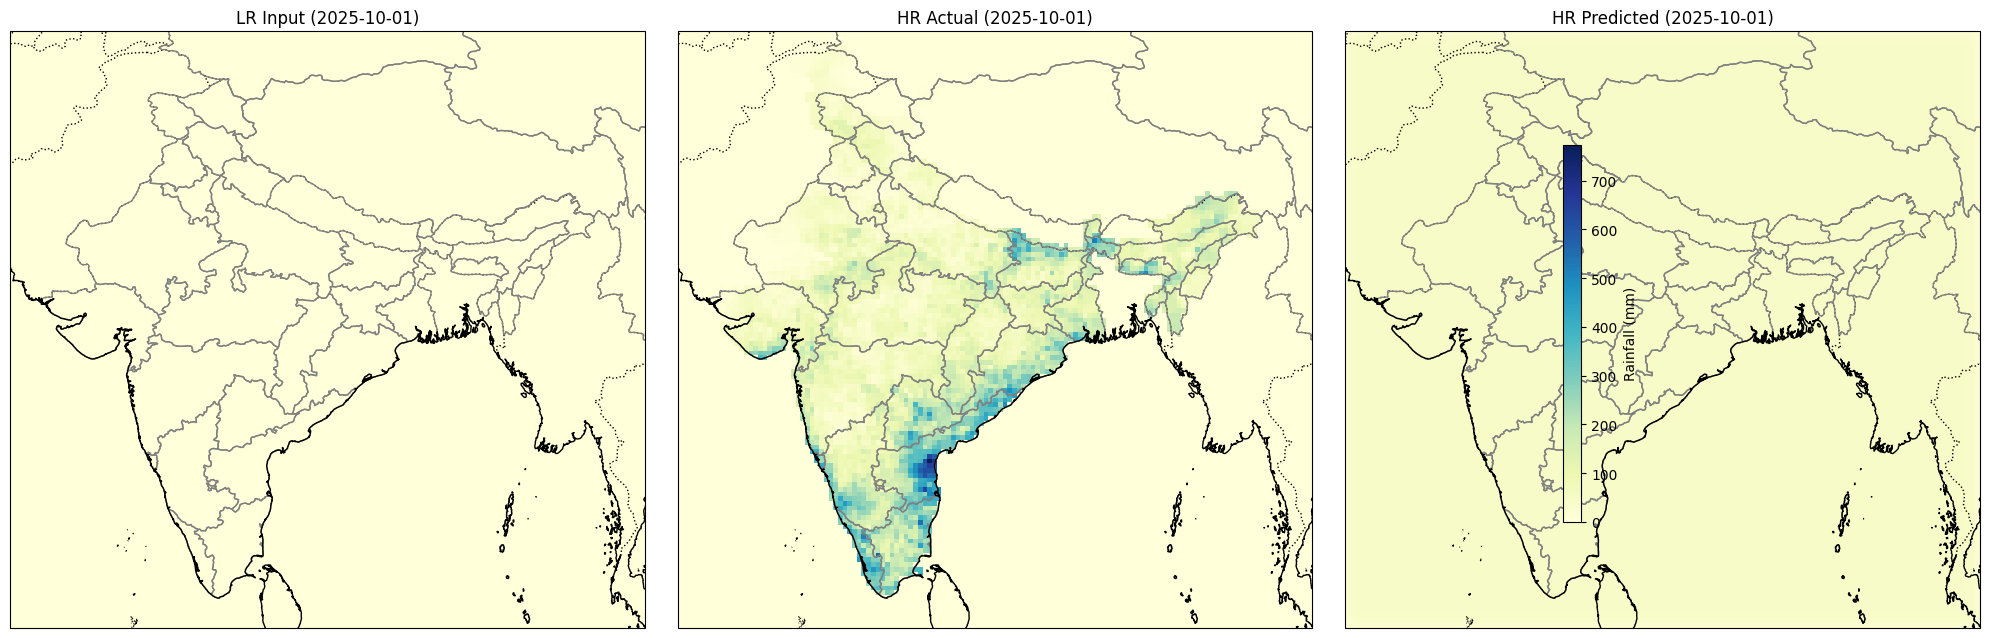

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Make predictions on the evaluation data
predictions = super_resolution_model.predict(lr_eval_np)

# 2. Evaluate the model
# Flatten the arrays for metric calculation if they are multidimensional images
# Reshape predictions and hr_eval_np to 2D arrays (samples, features) for sklearn metrics
predictions_flat = predictions.reshape(-1, 1)
hr_eval_flat = hr_eval_np.reshape(-1, 1)

mse = mean_squared_error(hr_eval_flat, predictions_flat)
mae = mean_absolute_error(hr_eval_flat, predictions_flat)

print(f"\nModel Evaluation on Validation Data:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# 3. Visualize a sample prediction
# Select the first sample from the evaluation set
sample_index = 0
lr_sample = lr_eval_np[sample_index, :, :, 0] # Remove channel dimension for plotting
hr_actual = hr_eval_np[sample_index, :, :, 0]
hr_predicted = predictions[sample_index, :, :, 0]

# Get the time for the sample
sample_time = hr_eval['time'].isel(time=sample_index).dt.strftime('%Y-%m-%d').item()

fig, axes = plt.subplots(1, 3, figsize=(20, 7), subplot_kw={'projection': ccrs.PlateCarree()})

vmin_val = min(lr_sample.min(), hr_actual.min(), hr_predicted.min())
vmax_val = max(lr_sample.max(), hr_actual.max(), hr_predicted.max())

# Plot Low-Resolution Input
im0 = axes[0].imshow(lr_sample, origin='lower', extent=[cropped_rainfall_data.LONGITUDE.min(), cropped_rainfall_data.LONGITUDE.max(), cropped_rainfall_data.LATITUDE.min(), cropped_rainfall_data.LATITUDE.max()],
                   cmap='YlGnBu', vmin=vmin_val, vmax=vmax_val)
axes[0].set_title(f'LR Input ({sample_time})')
axes[0].add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
axes[0].add_feature(cfeature.STATES, edgecolor='gray')
axes[0].coastlines(resolution='10m')

# Plot HR Actual
im1 = axes[1].imshow(hr_actual, origin='lower', extent=[cropped_rainfall_data.LONGITUDE.min(), cropped_rainfall_data.LONGITUDE.max(), cropped_rainfall_data.LATITUDE.min(), cropped_rainfall_data.LATITUDE.max()],
                   cmap='YlGnBu', vmin=vmin_val, vmax=vmax_val)
axes[1].set_title(f'HR Actual ({sample_time})')
axes[1].add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
axes[1].add_feature(cfeature.STATES, edgecolor='gray')
axes[1].coastlines(resolution='10m')

# Plot HR Predicted
im2 = axes[2].imshow(hr_predicted, origin='lower', extent=[cropped_rainfall_data.LONGITUDE.min(), cropped_rainfall_data.LONGITUDE.max(), cropped_rainfall_data.LATITUDE.min(), cropped_rainfall_data.LATITUDE.max()],
                   cmap='YlGnBu', vmin=vmin_val, vmax=vmax_val)
axes[2].set_title(f'HR Predicted ({sample_time})')
axes[2].add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
axes[2].add_feature(cfeature.STATES, edgecolor='gray')
axes[2].coastlines(resolution='10m')

fig.colorbar(im1, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.7, label='Rainfall (mm)')
plt.tight_layout()
plt.show()